In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


C:\Users\Svara\AppData\Local\Temp\ipykernel_14288\935385067.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, ax=axes[0], palette=["steelblue","crimson"])
C:\Users\Svara\AppData\Local\Temp\ipykernel_14288\935385067.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Legit (99.83%)", "Fraud (0.17%)"])


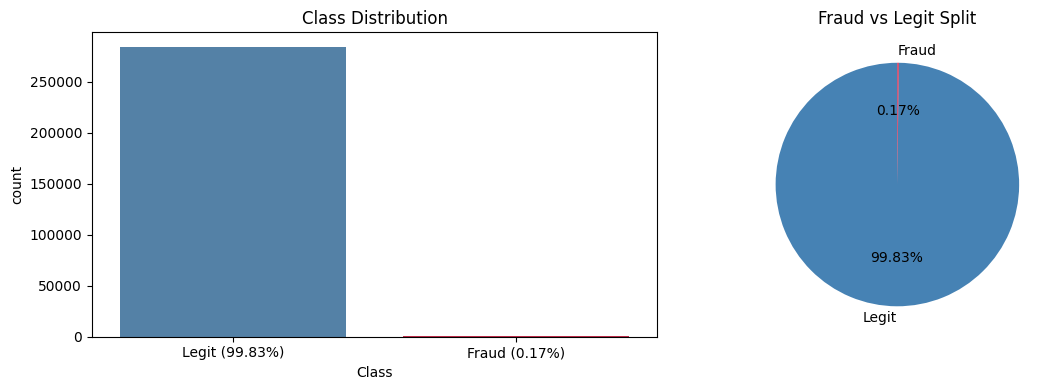

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x="Class", data=df, ax=axes[0], palette=["steelblue","crimson"])
axes[0].set_title("Class Distribution")
axes[0].set_xticklabels(["Legit (99.83%)", "Fraud (0.17%)"])

# Pie chart
axes[1].pie([len(df[df.Class==0]), len(df[df.Class==1])],
            labels=["Legit","Fraud"],
            colors=["steelblue","crimson"],
            autopct="%1.2f%%", startangle=90)
axes[1].set_title("Fraud vs Legit Split")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

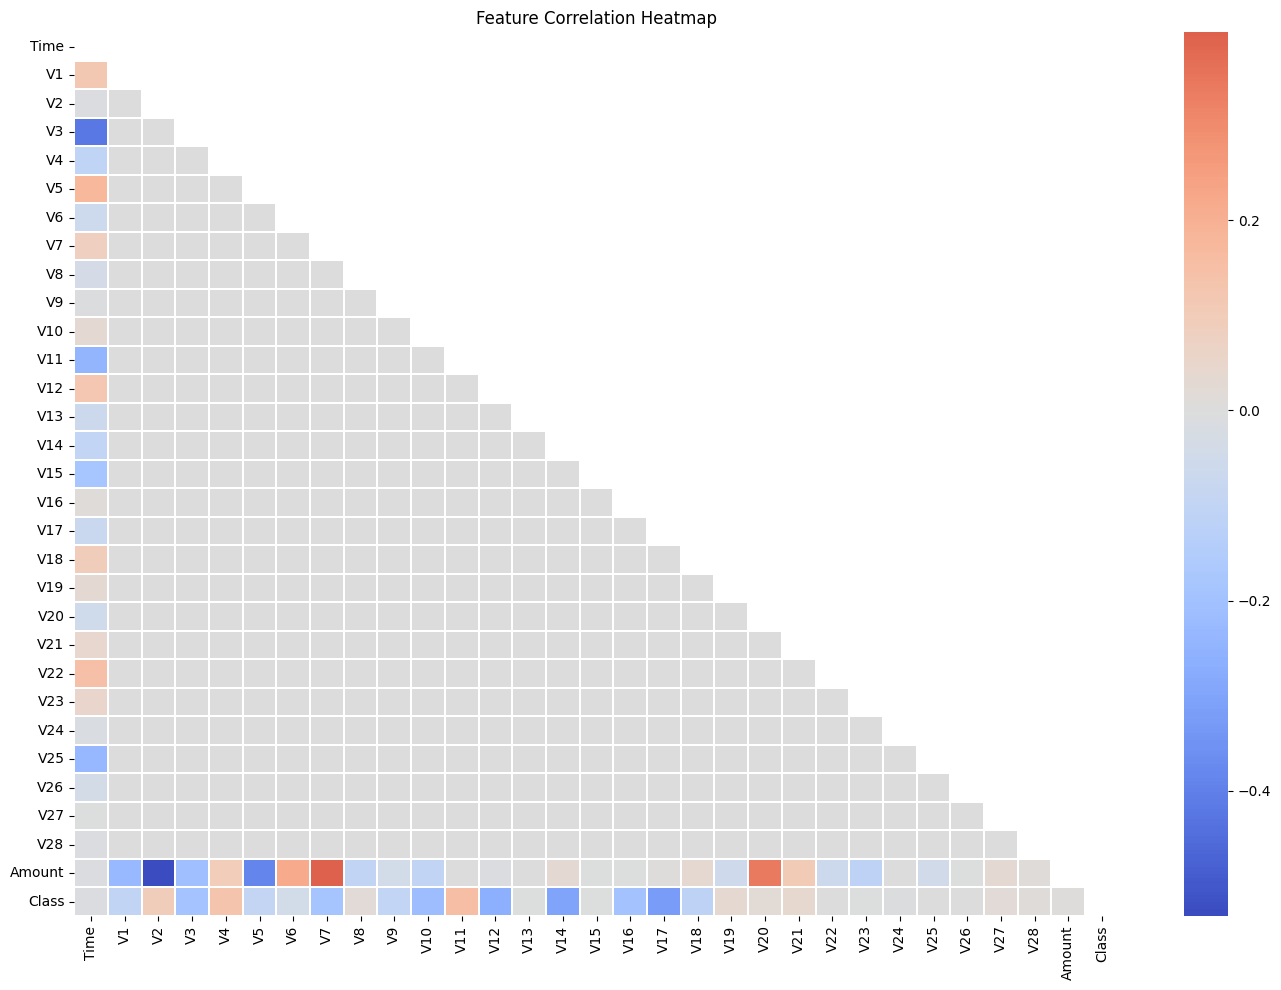

In [4]:
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            linewidths=0.3, annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

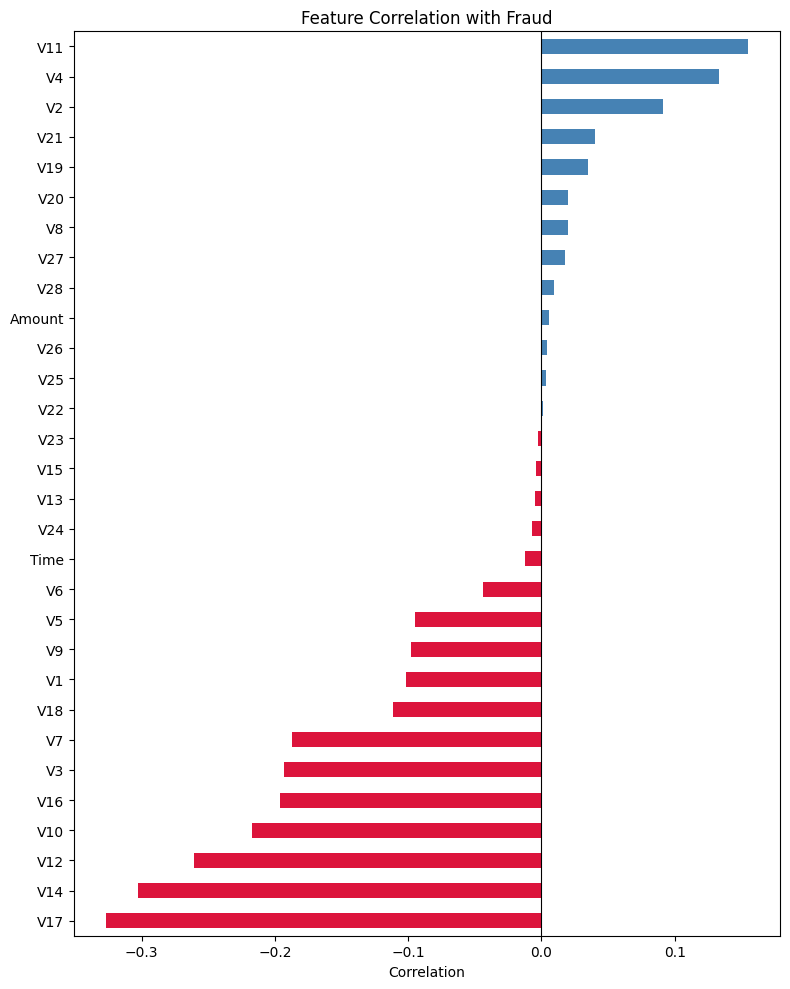

Top 5 features most correlated with FRAUD:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Top 5 features most negatively correlated:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [5]:
fraud_corr = df.corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ["crimson" if x < 0 else "steelblue" for x in fraud_corr]
fraud_corr.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Correlation with Fraud")
ax.set_xlabel("Correlation")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("fraud_correlation.png", dpi=150)
plt.show()

print("Top 5 features most correlated with FRAUD:")
print(fraud_corr.tail(5))
print("\nTop 5 features most negatively correlated:")
print(fraud_corr.head(5))

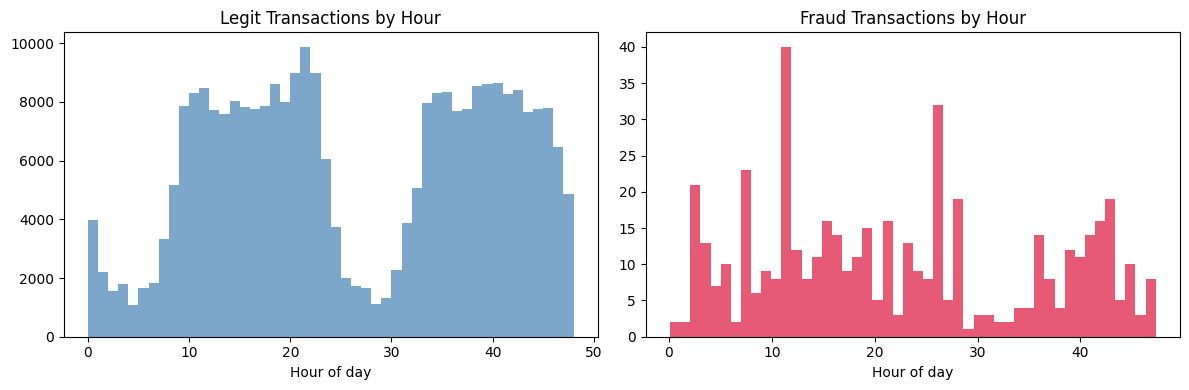

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df.Class==0]["Time"]/3600, bins=48,
             color="steelblue", alpha=0.7)
axes[0].set_title("Legit Transactions by Hour")
axes[0].set_xlabel("Hour of day")

axes[1].hist(df[df.Class==1]["Time"]/3600, bins=48,
             color="crimson", alpha=0.7)
axes[1].set_title("Fraud Transactions by Hour")
axes[1].set_xlabel("Hour of day")

plt.tight_layout()
plt.savefig("time_analysis.png", dpi=150)
plt.show()

In [7]:
print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)
print(f"Total transactions:     {len(df):,}")
print(f"Legitimate:             {len(df[df.Class==0]):,}")
print(f"Fraudulent:             {len(df[df.Class==1]):,}")
print(f"Fraud rate:             {df.Class.mean()*100:.3f}%")
print(f"Avg legit amount:       ₹{df[df.Class==0].Amount.mean():.2f}")
print(f"Avg fraud amount:       ₹{df[df.Class==1].Amount.mean():.2f}")
print(f"Time span:              {df.Time.max()/3600:.1f} hours")
print(f"Missing values:         {df.isnull().sum().sum()}")
print("=" * 40)

DATASET SUMMARY
Total transactions:     284,807
Legitimate:             284,315
Fraudulent:             492
Fraud rate:             0.173%
Avg legit amount:       ₹88.29
Avg fraud amount:       ₹122.21
Time span:              48.0 hours
Missing values:         0
